# 00 — Data Exploration

Explore the NIH ChestX-ray14 dataset before training.

**Covers**: label distribution, class imbalance, image statistics, sample visualisation.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

from src.data.extract import prepare_data, load_labels_dataframe
from src.utils.config import PATHOLOGY_CLASSES, Paths
print('Setup OK')

Setup OK


## 2. Load Labels

In [2]:
# Download labels CSV if not present
from src.data.extract import download_labels_csv
download_labels_csv()

df = load_labels_dataframe()
print(f'Total images: {len(df):,}')
print(f'Columns: {list(df.columns)}')
df.head(3)

2026-07-14 18:13:41 | INFO     | src.data.extract                    | Labels CSV already present: /teamspace/studios/this_studio/chest-xray-classifier/data/labels/Data_Entry_2017.csv
2026-07-14 18:13:41 | INFO     | src.data.extract                    | Loading NIH labels from /teamspace/studios/this_studio/chest-xray-classifier/data/labels/Data_Entry_2017.csv
2026-07-14 18:13:42 | INFO     | src.data.extract                    | Labels loaded: 112120 images, 40081 with at least one pathology
Total images: 112,120
Columns: ['image_id', 'label_str', 'patient_age', 'patient_gender', 'view_position', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'no_finding']


,image_id,label_str,patient_age,patient_gender,view_position,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,no_finding
0,00000001_000.png,Cardiomegaly,058Y,M,PA,0,1,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,058Y,M,PA,0,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,058Y,M,PA,0,1,0,0,1,0,0,0,0,0,0


## 3. Class Distribution (Imbalance)

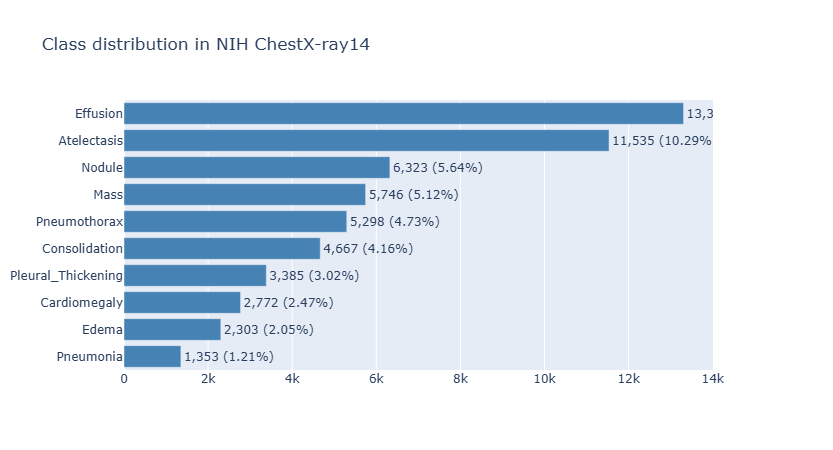

Most common: No Finding (~50% of dataset)


In [3]:
counts = df[PATHOLOGY_CLASSES].sum().sort_values(ascending=False)
pct    = (counts / len(df) * 100).round(2)

fig = go.Figure(go.Bar(
    x=counts.values, y=counts.index, orientation='h',
    marker_color='steelblue',
    text=[f'{c:,} ({p}%)' for c,p in zip(counts.values, pct.values)],
    textposition='outside'
))
fig.update_layout(
    title='Class distribution in NIH ChestX-ray14',
    yaxis={'autorange': 'reversed'}, height=450, margin=dict(l=10, r=120)
)
fig.show()
print('Most common: No Finding (~50% of dataset)')

## 4. Multi-label Co-occurrence

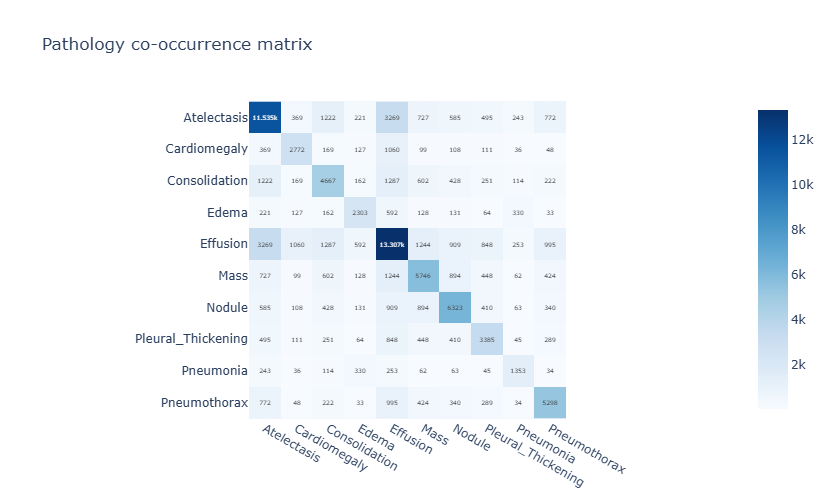

In [4]:
# How often do pathologies appear together?
from itertools import combinations
import numpy as np

cooc = np.zeros((len(PATHOLOGY_CLASSES), len(PATHOLOGY_CLASSES)))
for i, ci in enumerate(PATHOLOGY_CLASSES):
    for j, cj in enumerate(PATHOLOGY_CLASSES):
        cooc[i, j] = (df[ci] & df[cj]).sum()

fig = px.imshow(
    cooc, x=PATHOLOGY_CLASSES, y=PATHOLOGY_CLASSES,
    title='Pathology co-occurrence matrix',
    color_continuous_scale='Blues', text_auto=True,
)
fig.update_layout(height=500)
fig.show()

## 5. Sample Images

24,999 / 112,120 labelled images available on disk


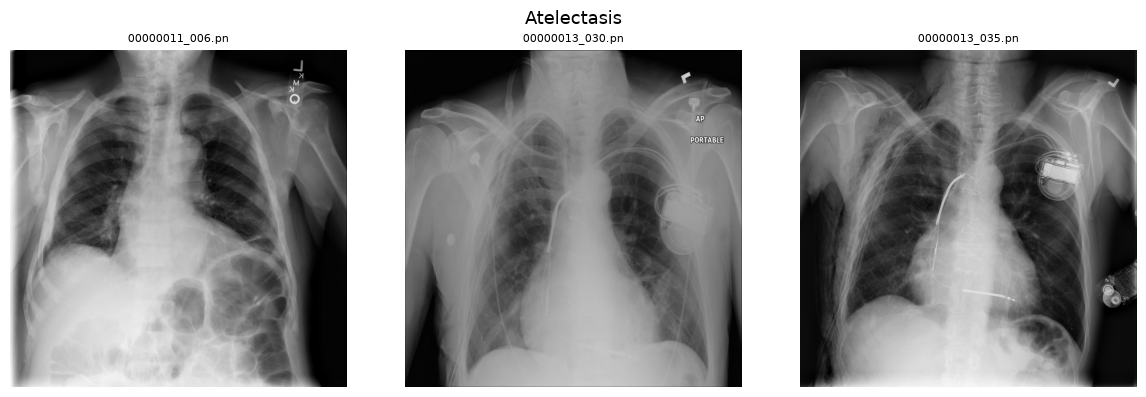

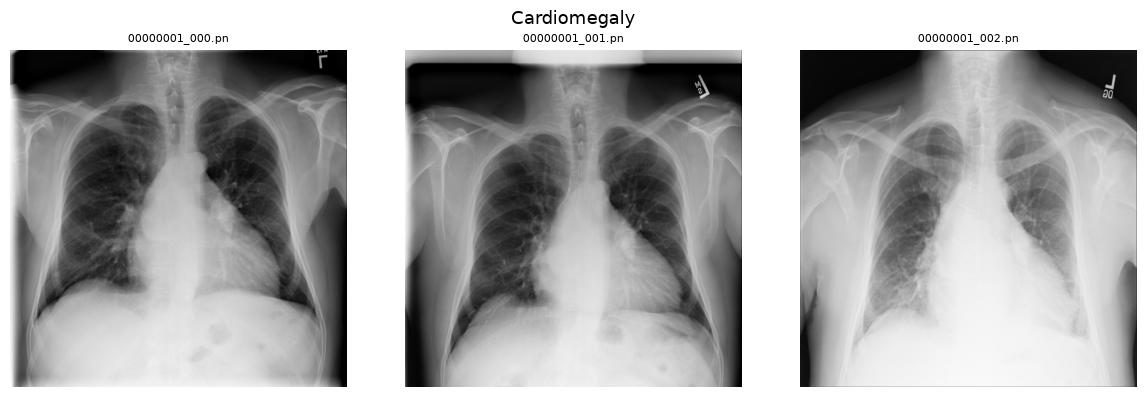

In [ ]:
from src.utils.image_utils import load_xray, get_image_stats
from src.utils.config import PATHOLOGY_CLASSES
import matplotlib.pyplot as plt

# Show sample images for each class (requires images downloaded).
# In subset mode only ~500 of the 112,120 labelled images exist on disk,
# so filter to images that are actually present before sampling -
# otherwise most classes end up with no available example.
image_dir = Paths.images_dir()
existing_ids = {p.name for p in image_dir.glob('*.png')}
df_available = df[df['image_id'].isin(existing_ids)]
print(f'{len(df_available):,} / {len(df):,} labelled images available on disk')

for cls in PATHOLOGY_CLASSES[:4]:
    sample_ids = df_available[df_available[cls] == 1]['image_id'].head(3).tolist()
    if not sample_ids:
        print(f'{cls}: no locally available sample images')
        continue
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(cls, fontsize=13)
    axes = [axes] if len(sample_ids) == 1 else axes
    for ax, img_id in zip(axes, sample_ids):
        ax.imshow(load_xray(image_dir / img_id), cmap='gray')
        ax.set_title(img_id[:15], fontsize=8)
        ax.axis('off')
    for ax in axes[len(sample_ids):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()